# Previsione della popolarità dei brani Spotify

Progetto di Programmazione di Applicazioni Data Intensive a.a. 2025/26  
Realizzato da Ciro Bassi (ciro.bassi@studio.unibo.it) e Alessandro Testa (alessandro.testa9@studio.unibo.it)

## Descrizione del problema

L'obiettivo del progetto è quello di sviluppare un modello in grado di predire la popolarità di un brano su Spotify sulla base di specifiche caratteristiche audio e descrittive del brano.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Caricamento dei dati
Questo dataset, ottenuto da [Kaggle](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset/data), contiene un insieme di brani Spotify, appartenenti a diversi generi musicali, corredati delle rispettive caratteristiche audio.

### Feature del Dataset
- `track_id`: Spotify ID del brano
- `artists`: artista o gruppo che esegue il brano
- `album_name`: nome dell’album in cui è contenuto il brano
- `track_name`: titolo della traccia
- `duration_ms`: durata del brano in millisecondi
- `explicit`: indica se il brano contiene contenuti espliciti (True/False)
- `danceability`: misura quanto il brano è "ballabile"
- `energy`: livello di intensità e di energia del brano
- `key`: tonalità musicale del brano (codificata numericamente: 0=C, 1=C#/Db, 2=D,...)
- `loudness`: volume medio del brano in decibel
- `mode`: modalità musicale (maggiore = 1, minore = 0)
- `speechiness`: presenza di parlato nel brano
- `acousticness`: probabilità che il brano sia acustico
- `instrumentalness`: probabilità che il brano sia strumentale (senza voce)
- `liveness`: probabilità che il brano sia registrato dal vivo
- `valence`: misura della positività/“felicità” del brano
- `tempo`: velocità del brano in BPM (battiti per minuto)
- `time_signature`: numero di battiti per misura (valori compresi tra 3 (3/4) e 7 (7/4))
- `track_genre`: genere musicale del brano

La variabile target da predirre è `popularity`, l'indice di popolarità del brano (di solito da 0 a 100)

In [2]:
import os.path
file = "dataset.csv";
if not os.path.exists(file):
    print("Missing dataset");

df = pd.read_csv(file, index_col=0);

In [3]:
df.info(verbose=False, memory_usage="deep");

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), float64(9), int64(5), str(5)
memory usage: 48.8 MB


In [4]:
df.head(1)

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.143,0.0322,0.000001,0.358,0.715,87.917,4,acoustic


Si osserva che le colonne `artists`, `album_name` e `track_genre` possono essere categorizzate, per ottimizzare lo spazio in memoria.
Si procede quindi a ricaricare il DataFrame.

In [5]:
categorical = ["artists", "album_name", "track_genre"]
df = pd.read_csv(file, index_col=0, dtype={col: "category" for col in categorical})
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Columns: 20 entries, track_id to track_genre
dtypes: bool(1), category(3), float64(9), int64(5), str(2)
memory usage: 36.0 MB


Si può osservare come l’utilizzo di memoria risulti significativamente ridotto rispetto alla situazione iniziale.

### Prima scrematura dei dati
Prima di procedere con l’analisi dei dati, si effettua una prima fase di scrematura.

Eliminazione di tutte le righe in cui la colonna `popularity` assume valore pari a 0.

In [6]:
df = df[df['popularity'] != 0]

Eliminazione dei brani duplicati, identificati da combinazioni di stesso nome e stesso artista, mantenendo per ciascun caso l’osservazione con il valore di popolarità più elevato.

In [7]:
df = df.sort_values('popularity', ascending=False).drop_duplicates(subset=['track_name', 'artists'])

Gestione degli eventuali valori nulli presenti nel dataset.

In [8]:
df.isnull().sum()
df = df.dropna()

Rimozione della colonna `track_id`, non necessaria.

In [9]:
df.drop(columns=["track_id"], inplace=True);

Conversione dei millisecondi in secondi.

In [10]:
df['duration_s'] = df['duration_ms'] / 1000
df = df.drop(columns=['duration_ms'])

Creazione di una colonna con numero di artisti per ogni brano.

In [11]:
df['num_artists'] = df['artists'].astype(str).str.split(';').str.len()

In [12]:
df.head(1)

,artists,album_name,track_name,popularity,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,duration_s,num_artists
20001,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,False,0.714,0.472,2,-7.375,1,0.0864,0.013,0.000005,0.266,0.238,131.121,4,dance,156.943,2


Con questa prima scrematura, la dimensione del dataset è stata ridotta ulteriormente.

In [13]:
df.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76585 entries, 20001 to 60590
Columns: 20 entries, artists to num_artists
dtypes: bool(1), category(3), float64(10), int64(5), str(1)
memory usage: 23.0 MB


## Analisi esplorativa dei dati
Si procede con la visualizzazione di alcune statistiche descrittive relative ai dati oggetto di analisi.

In [14]:
print('tracks: \t' + str(len(df)))
print('artists:\t' + str(df['artists'].nunique()))
print('albums: \t' + str(df.groupby(['album_name', 'artists'], observed=True).ngroups))
print('genres: \t' + str(df['track_genre'].nunique()))

tracks: 	76585
artists:	29826
albums: 	53196
genres: 	114


Il dataset contiene quindi informazioni relative a 76585 diversi brani, 29826 artisti, 44621 album e 114 generi musicali.

In [15]:
def plot_bar(feature, n=None, title=None, bins=None, labels=None):
    col = df[feature]
    
    if bins is not None:
        col = pd.cut(col, bins=bins, labels=labels, include_lowest=True)
        values = col.value_counts()
        if labels is not None:
            values = values.reindex(labels)  # mantiene l'ordine low -> medium -> high
    else:
        values = col.value_counts()
    
    if n is not None:
        values = values.head(n)
    
    colors = [f"#{np.random.randint(0, 0xFFFFFF):06x}" for _ in range(len(values))]
    ax = values.plot.bar(figsize=(15, 4), color=colors)
    ax.set_title(title)
    plt.xticks(rotation=0)
    plt.show()

Di seguito vengono visualizzati alcuni istogrammi e statistiche per analizzare la distribuzione dei dati.

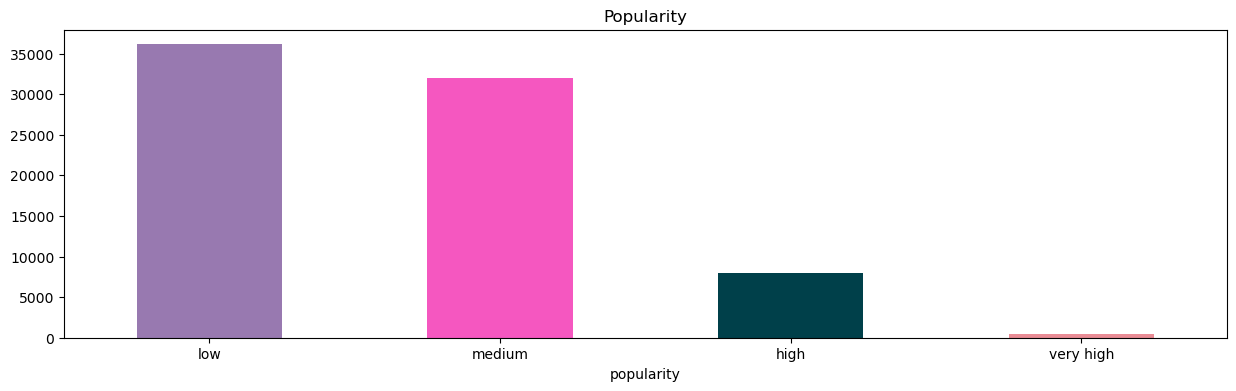

count    76585.000000
mean        37.439303
std         17.837212
min          1.000000
25%         23.000000
50%         37.000000
75%         50.000000
max        100.000000
Name: popularity, dtype: float64

In [16]:
plot_bar('popularity',
         bins=[0, 35, 60, 80, 100],
         labels=['low', 'medium', 'high', 'very high'],
         title='Popularity')
df["popularity"].describe()

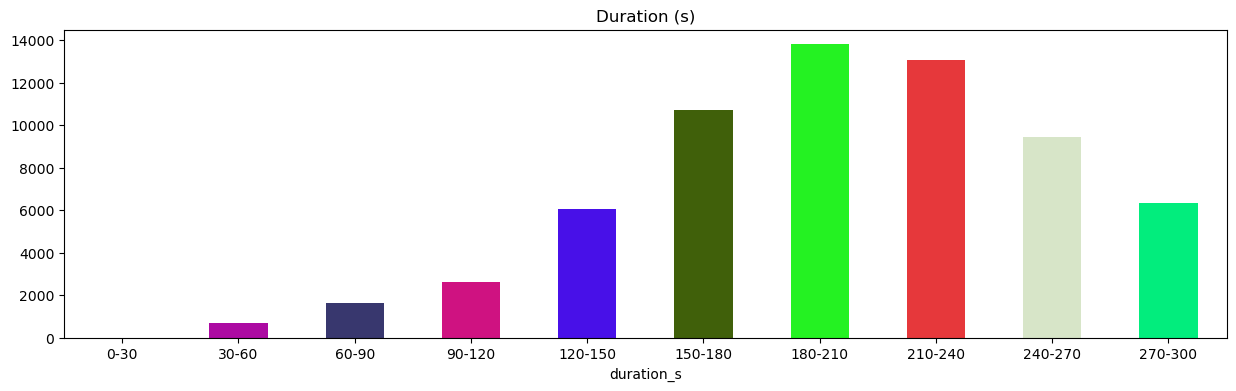

count    76585.000000
mean       231.499167
std        116.630574
min         24.266000
25%        173.973000
50%        215.689000
75%        267.847000
max       5237.295000
Name: duration_s, dtype: float64

In [17]:
plot_bar('duration_s',
         bins=[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300],
         labels=['0-30', '30-60', '60-90', '90-120', '120-150', '150-180', '180-210', '210-240', '240-270', '270-300'],
         title='Duration (s)')
df["duration_s"].describe()

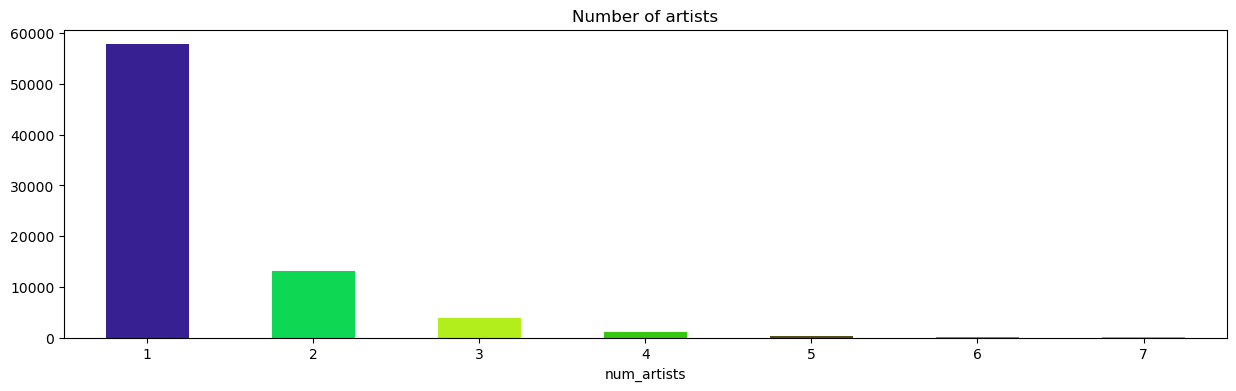

count    76585.000000
mean         1.368036
std          0.881734
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         38.000000
Name: num_artists, dtype: float64

In [18]:
plot_bar("num_artists", 7, "Number of artists")
df["num_artists"].describe()

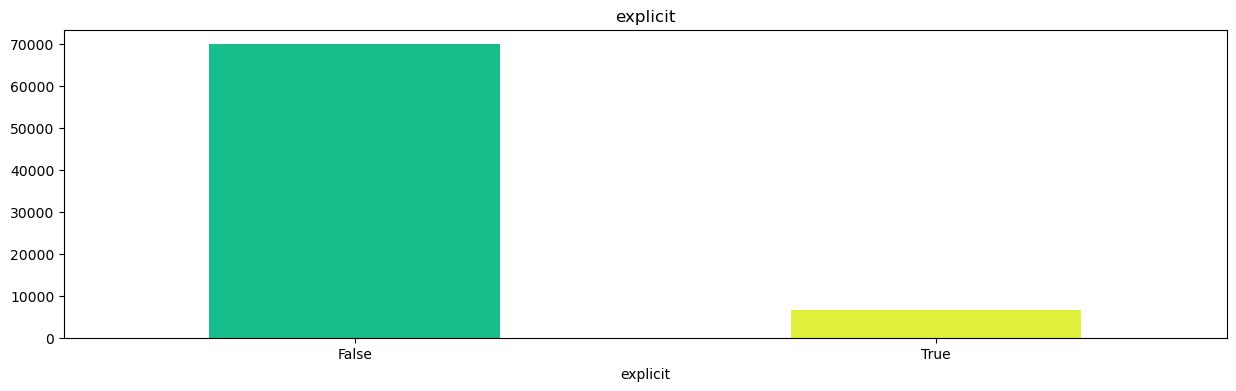

In [19]:
plot_bar("explicit", 2, "explicit")

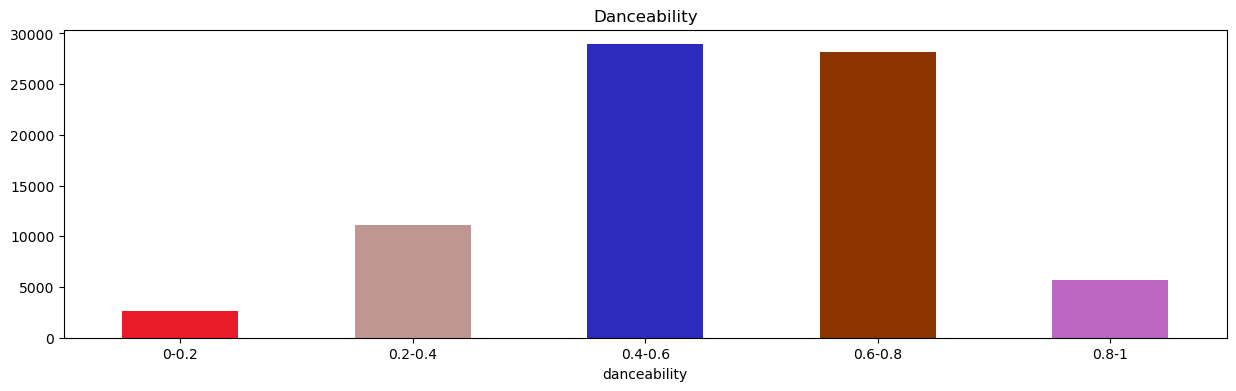

count    76585.000000
mean         0.561695
std          0.176131
min          0.000000
25%          0.450000
50%          0.575000
75%          0.691000
max          0.985000
Name: danceability, dtype: float64

In [20]:
plot_bar('danceability',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Danceability')
df["danceability"].describe()

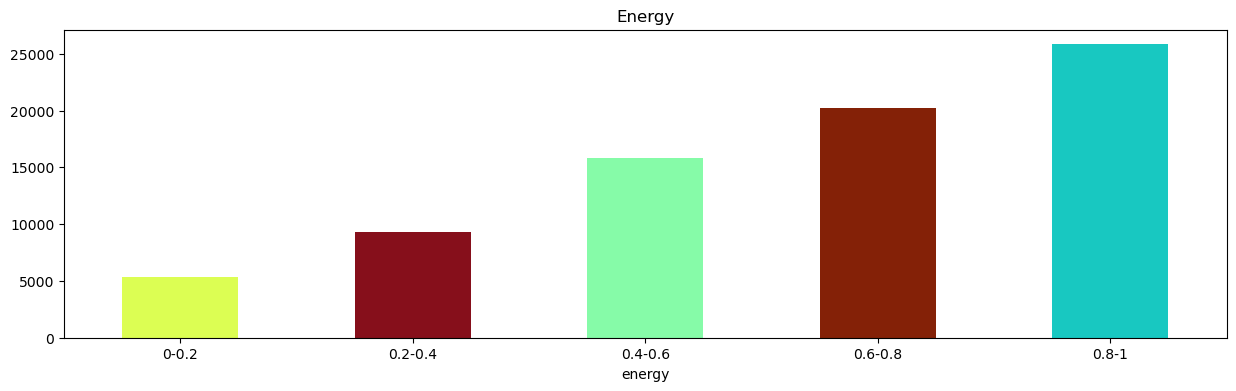

count    76585.000000
mean         0.640234
std          0.255269
min          0.000000
25%          0.464000
50%          0.682000
75%          0.859000
max          1.000000
Name: energy, dtype: float64

In [21]:
plot_bar('energy',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Energy')
df["energy"].describe()

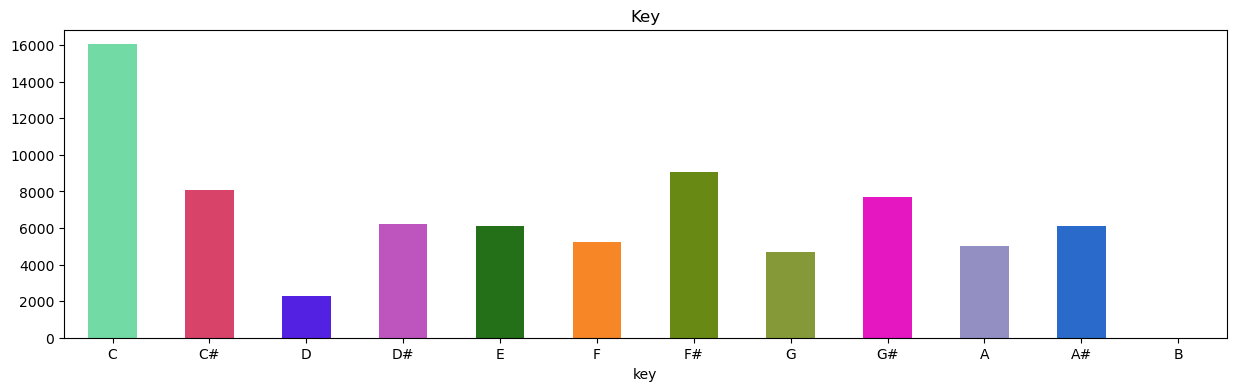

In [22]:
plot_bar('key',
         bins=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
         labels=['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B'],
         title='Key')

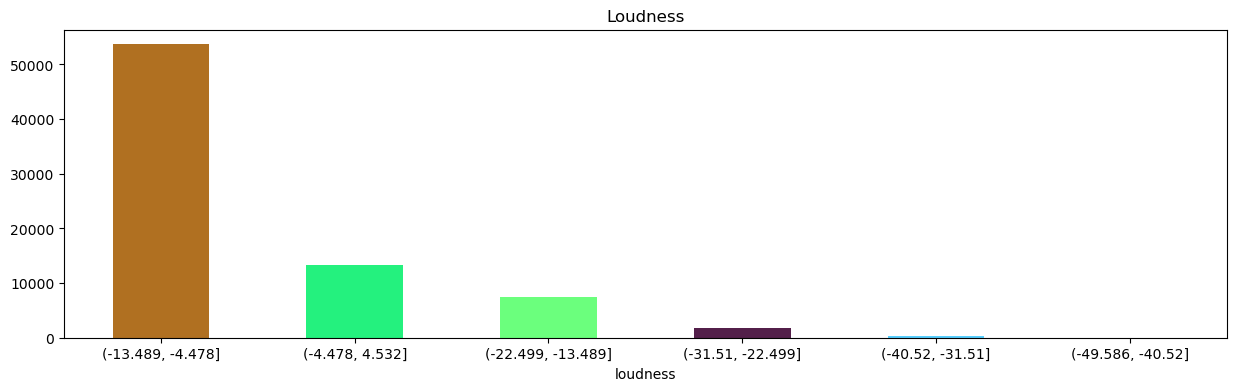

count    76585.000000
mean        -8.496698
std          5.187510
min        -49.531000
25%        -10.327000
50%         -7.232000
75%         -5.130000
max          4.532000
Name: loudness, dtype: float64

In [23]:
plot_bar('loudness',
         bins=6,
         title='Loudness')
df["loudness"].describe()

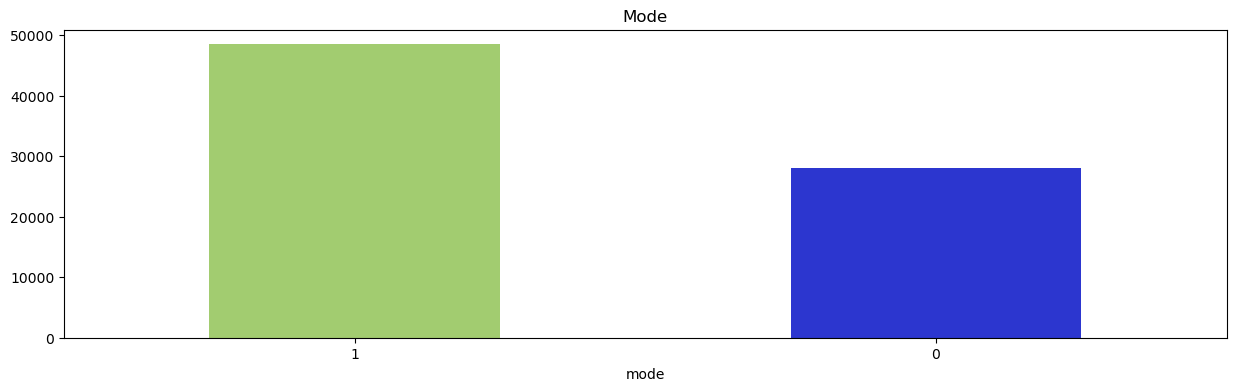

In [24]:
plot_bar("mode", 2, "Mode")

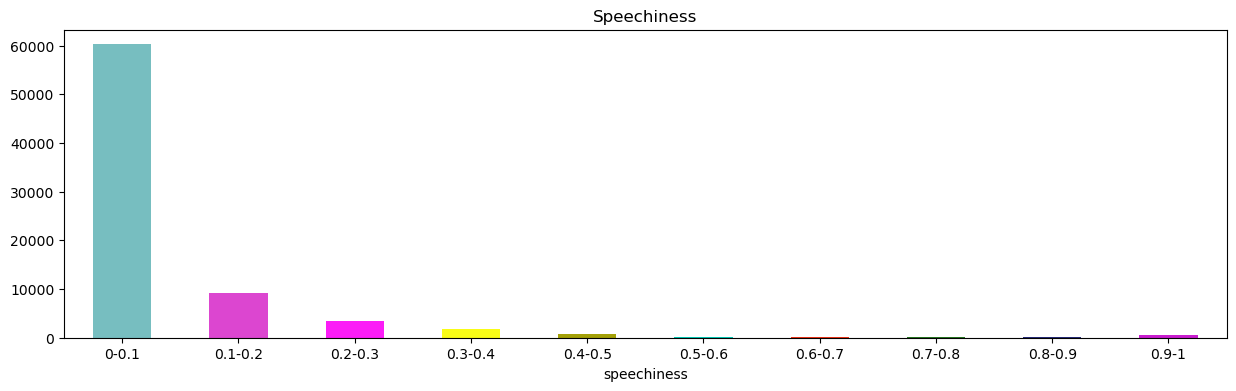

count    76585.000000
mean         0.089653
std          0.118414
min          0.000000
25%          0.036000
50%          0.049200
75%          0.087600
max          0.965000
Name: speechiness, dtype: float64

In [25]:
plot_bar('speechiness',
         bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
         labels=['0-0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1'],
         title='Speechiness')
df["speechiness"].describe()

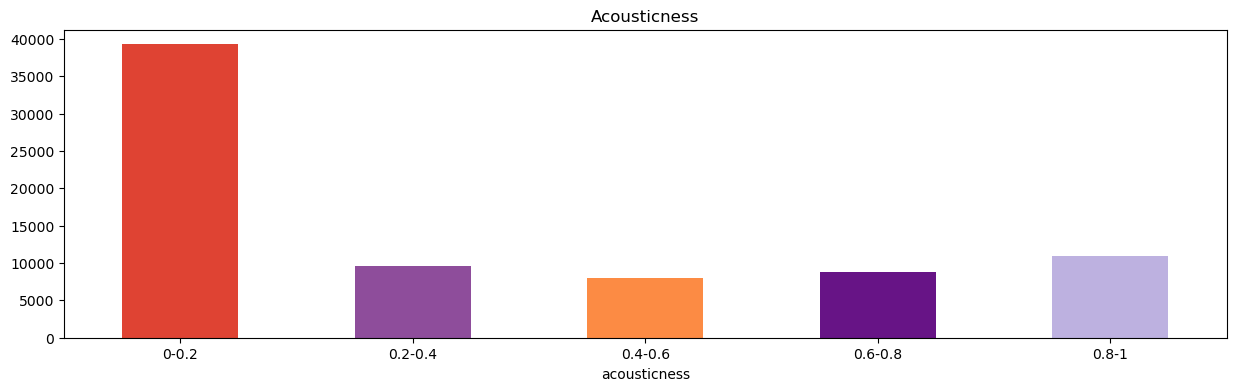

count    76585.000000
mean         0.322805
std          0.335335
min          0.000000
25%          0.015000
50%          0.184000
75%          0.614000
max          0.996000
Name: acousticness, dtype: float64

In [26]:
plot_bar('acousticness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Acousticness')
df["acousticness"].describe()

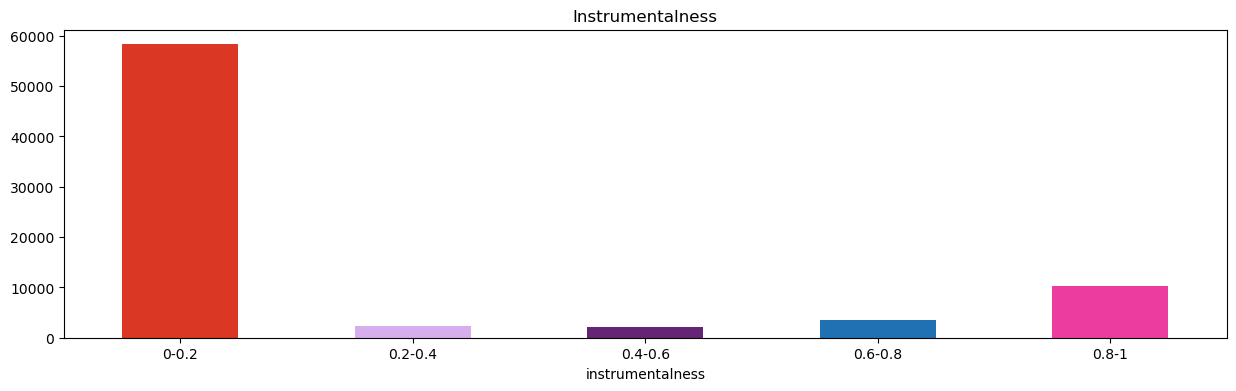

count    76585.000000
mean         0.183126
std          0.330334
min          0.000000
25%          0.000000
50%          0.000085
75%          0.144000
max          1.000000
Name: instrumentalness, dtype: float64

In [27]:
plot_bar('instrumentalness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Instrumentalness')
df["instrumentalness"].describe()

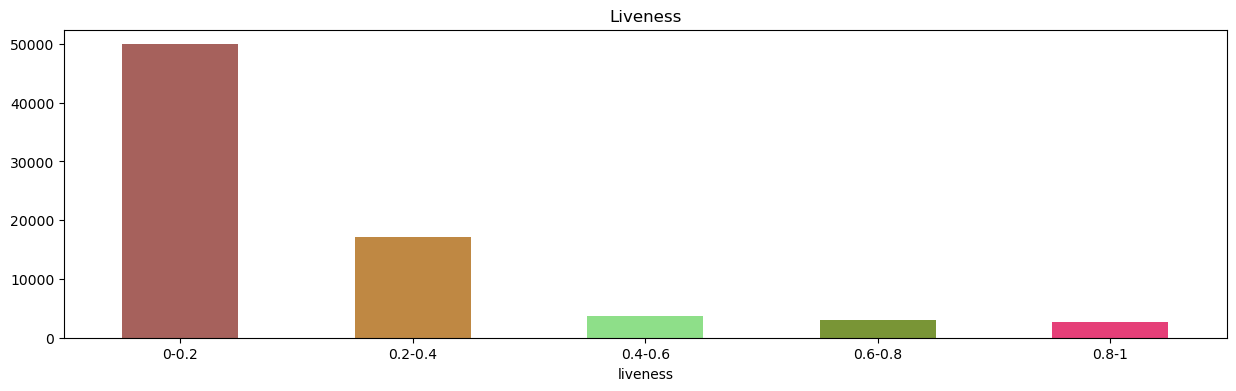

count    76585.000000
mean         0.221368
std          0.200116
min          0.000000
25%          0.098700
50%          0.133000
75%          0.285000
max          1.000000
Name: liveness, dtype: float64

In [28]:
plot_bar('liveness',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Liveness')
df["liveness"].describe()

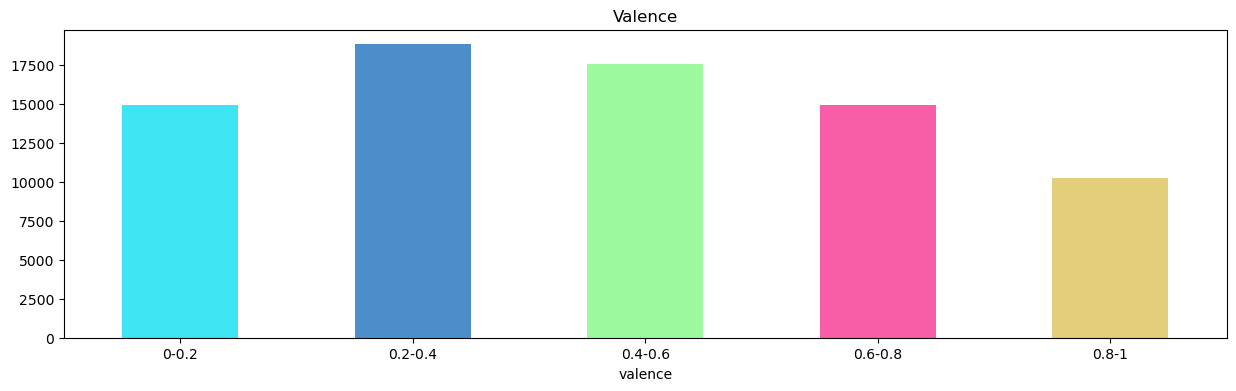

count    76585.000000
mean         0.465632
std          0.262399
min          0.000000
25%          0.246000
50%          0.451000
75%          0.677000
max          0.995000
Name: valence, dtype: float64

In [29]:
plot_bar('valence',
         bins=[0, 0.2, 0.4, 0.6, 0.8, 1],
         labels=['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1'],
         title='Valence')
df["valence"].describe()

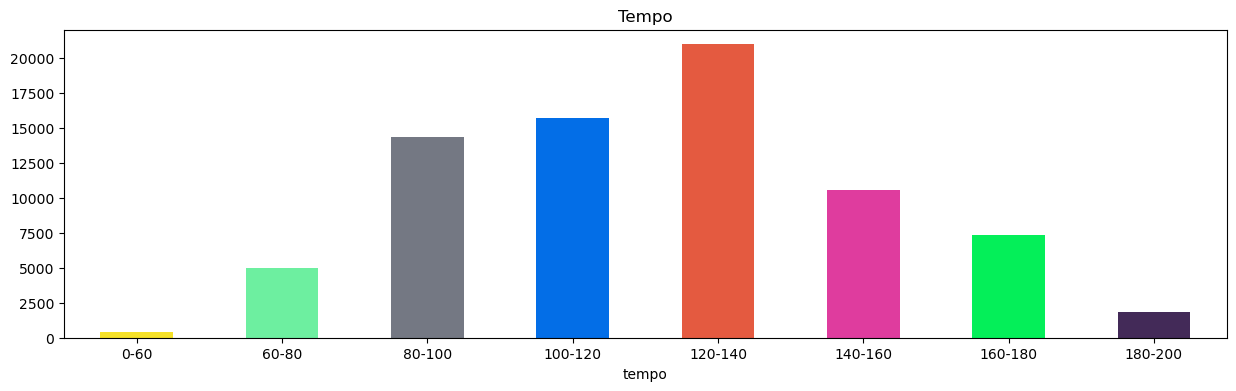

count    76585.000000
mean       122.416330
std         30.075551
min          0.000000
25%         99.915000
50%        122.369000
75%        140.655000
max        243.372000
Name: tempo, dtype: float64

In [30]:
plot_bar('tempo',
         bins=[0, 60, 80, 100, 120, 140, 160, 180, 200],
         labels=['0-60', '60-80', '80-100', '100-120', '120-140', '140-160', '160-180', '180-200'],
         title='Tempo')
df["tempo"].describe()

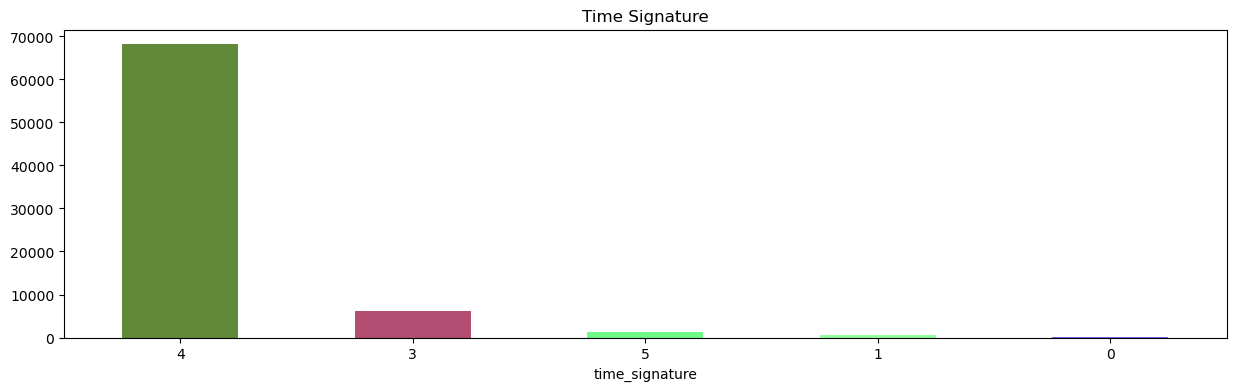

In [31]:
plot_bar("time_signature", 5, "Time Signature")

plot_bar("track_genre", 10, "Genre")

## Preparazione dei dati

Creazione di una copia del dataset, rimozione delle feature inutilizzate.

In [32]:
df_model = df.copy()
df_model = df_model.drop(columns=['artists', 'album_name', 'track_name'])

Rimozione dei brani con caratteristiche anomale.

In [33]:
df_model = df_model[(df_model['duration_s'] >= 30) & (df_model['duration_s'] <= 1800)]
df_model = df_model[(df_model['loudness'] >= -60) & (df_model['loudness'] <= 0)]
df_model = df_model[(df_model['tempo'] >= 30) & (df_model['tempo'] <= 300)]

Conversione da bool a int

In [34]:
df_model['explicit'] = df_model['explicit'].astype(int)

Conversione delle feature categoriche in valori numerici

In [35]:
df_model = pd.get_dummies(df_model, columns=['track_genre'], drop_first=True)

In [36]:
df_model.info(verbose=False, memory_usage="deep")

<class 'pandas.DataFrame'>
Index: 76355 entries, 20001 to 60590
Columns: 129 entries, popularity to track_genre_world-music
dtypes: bool(113), float64(10), int64(6)
memory usage: 18.1 MB


### Train-test set

In [37]:
print('ciao')

ciao


## Preparazione del modello
Dopo aver effettuato la pulizia e la preparazione dei dati, si procede con la fase di costruzione del modello.

In [38]:
print('ciao')

ciao


## Conclusioni
In conclusione, il progetto ha permesso di sviluppare un modello in grado di stimare la popolarità dei brani Spotify a partire dalle loro caratteristiche. I risultati ottenuti mostrano come alcune variabili risultino più rilevanti di altre nel determinare il successo di un brano, evidenziando l’importanza dell’analisi dei dati nel comprendere fenomeni complessi.

Pur fornendo prestazioni soddisfacenti, il modello presenta margini di miglioramento, legati sia alla qualità dei dati sia alla possibile integrazione di ulteriori variabili. In prospettiva, l’affinamento delle tecniche di modellazione e l’ampliamento del dataset potrebbero contribuire a ottenere previsioni ancora più accurate.